Saving WhatsApp Image 2025-11-14 at 02.13.01.jpeg to WhatsApp Image 2025-11-14 at 02.13.01 (1).jpeg


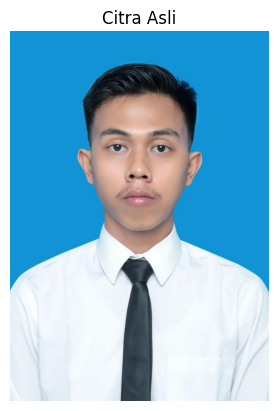

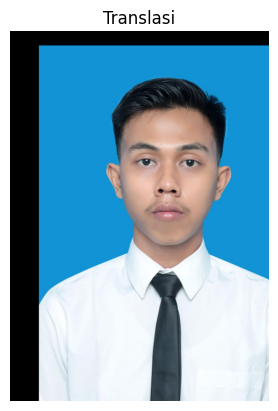

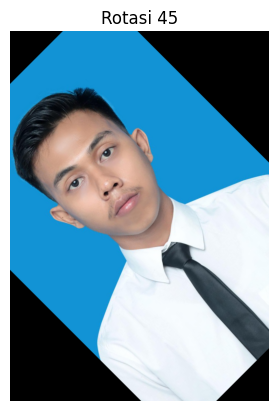

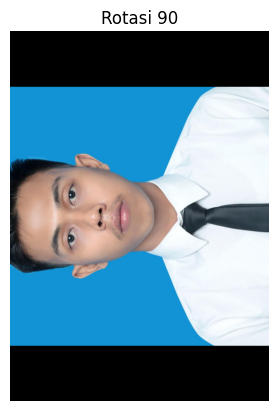

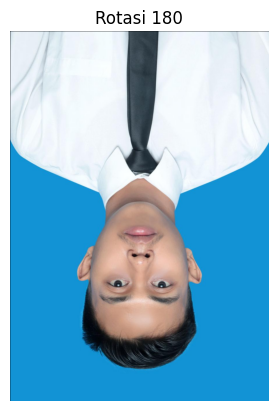

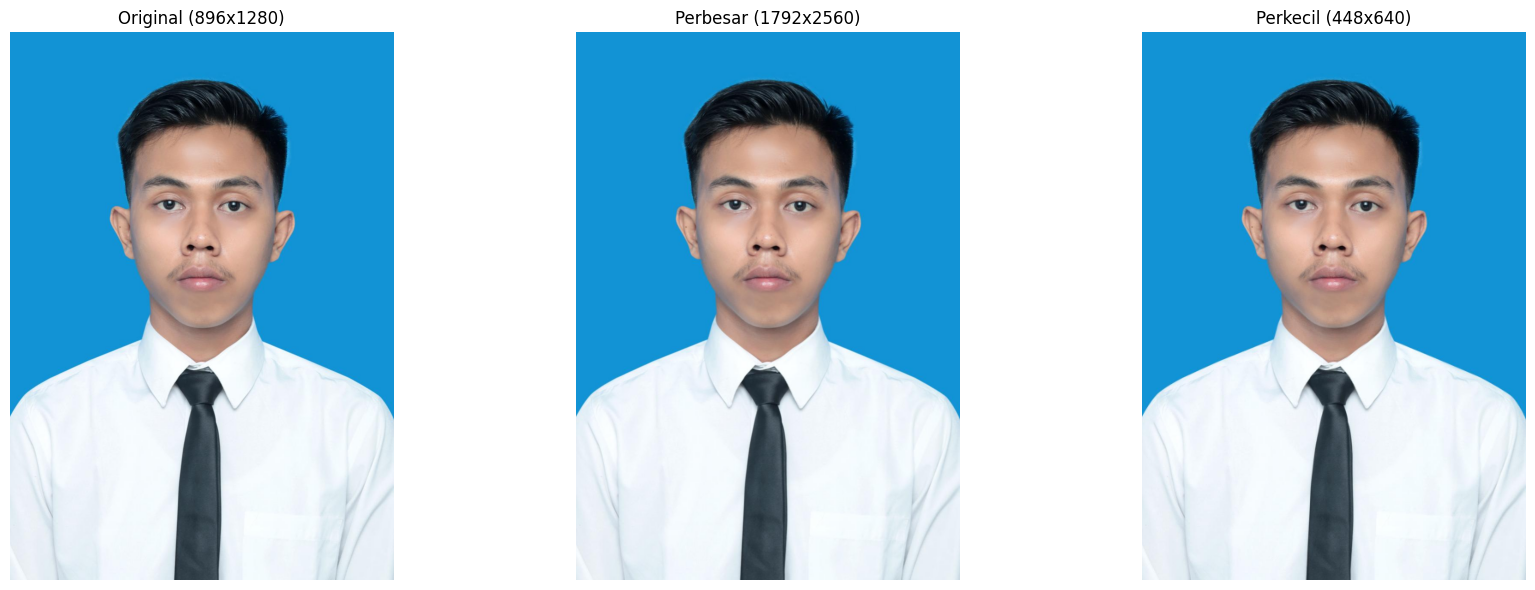

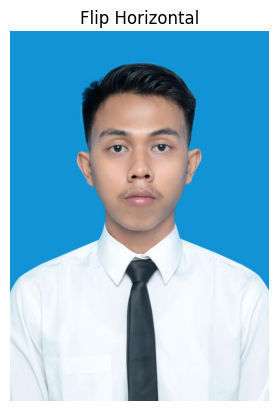

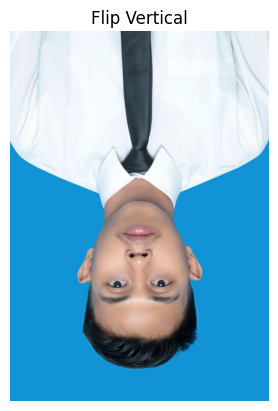

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload gambar
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Baca gambar
image = cv2.imread(filename)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Fungsi tampil
def show(img, title):
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

show(image_rgb, "Citra Asli")

# TRANSLASI
M = np.float32([[1,0,100],[0,1,50]])
trans = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))
show(cv2.cvtColor(trans, cv2.COLOR_BGR2RGB), "Translasi")

# ROTASI
def rotate(img, angle):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    return cv2.warpAffine(img, M, (w, h))

for a in [45, 90, 180]:
    r = rotate(image, a)
    show(cv2.cvtColor(r, cv2.COLOR_BGR2RGB), f"Rotasi {a}")

# SCALING
besar = cv2.resize(image, None, fx=2, fy=2)
kecil = cv2.resize(image, None, fx=0.5, fy=0.5)

# Display original, magnified, and minified images together for comparison
plt.figure(figsize=(18, 6)) # Adjust figure size to accommodate three images

plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
plt.imshow(image_rgb)
plt.title(f"Original ({image.shape[1]}x{image.shape[0]})")
plt.axis('off')

plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
plt.imshow(cv2.cvtColor(besar, cv2.COLOR_BGR2RGB))
plt.title(f"Perbesar ({besar.shape[1]}x{besar.shape[0]})")
plt.axis('off')

plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
plt.imshow(cv2.cvtColor(kecil, cv2.COLOR_BGR2RGB))
plt.title(f"Perkecil ({kecil.shape[1]}x{kecil.shape[0]})")
plt.axis('off')

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

# FLIP
h = cv2.flip(image,1)
v = cv2.flip(image,0)

show(cv2.cvtColor(h, cv2.COLOR_BGR2RGB), "Flip Horizontal")
show(cv2.cvtColor(v, cv2.COLOR_BGR2RGB), "Flip Vertical")

In [6]:
print(f"Original image shape: {image.shape}")
print(f"Magnified image shape: {besar.shape}")
print(f"Minified image shape: {kecil.shape}")

Original image shape: (1280, 896, 3)
Magnified image shape: (2560, 1792, 3)
Minified image shape: (640, 448, 3)


As you can see from the output above, the actual dimensions (width, height, and channels) of the `besar` (magnified) and `kecil` (minified) images are indeed different from the original image and from each other. The `cv2.resize` function successfully changed their sizes, but `matplotlib.pyplot.imshow` often scales images to fit the display area, which can make them *look* like they have the same size in the output.